First order LQU - Concurrence 

C:\Users\Deanna-Troi\AppData\Local\Temp\ipykernel_6460\835277364.py:98: RuntimeWarning: invalid value encountered in log
  logconc = np.log(np.abs(lambda3(x_b) / z(x_b)) * np.sqrt(1 + 4 * (alpha**2) * (Imf(w))**2) - 2 * lambda4(x_b) / z(x_b))


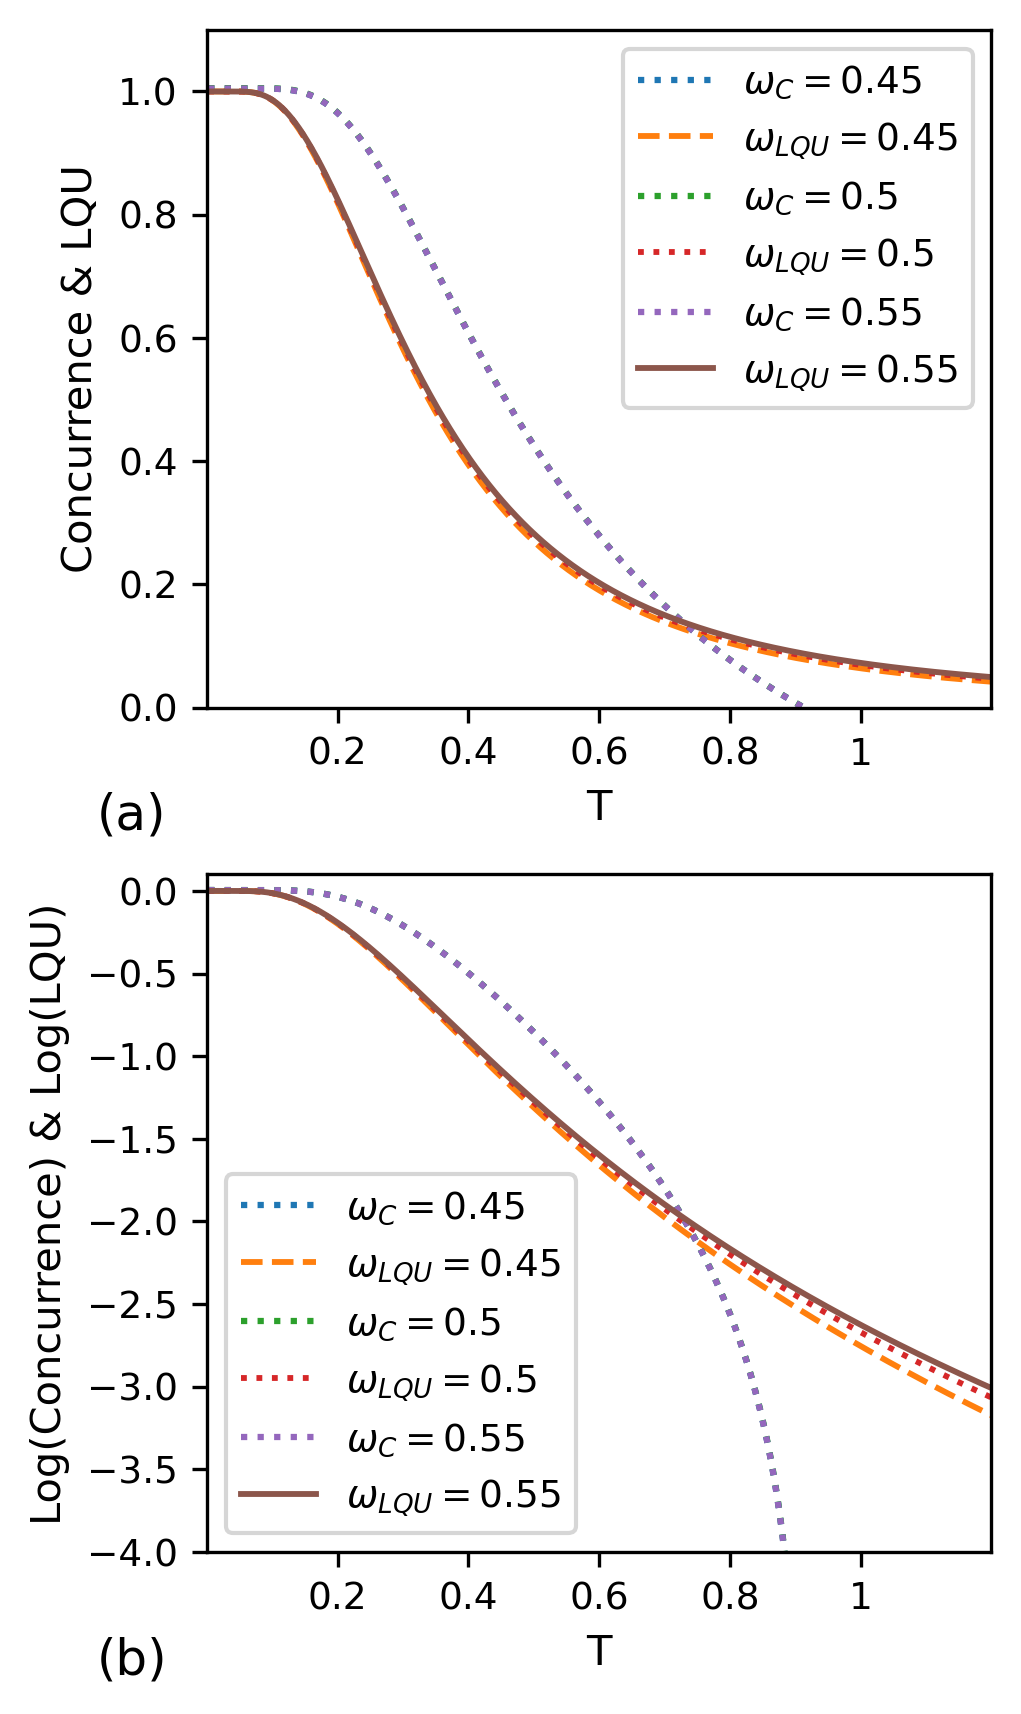

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#parameters

d= .2
alpha= 0.01
beta,J= 1,.5

#partition function

def z(x):
    z = (np.exp(.75*beta*J/x) + 3*np.exp(-.25*beta*J/x))
    return z


def Imf(x):
    Imf= 2*d*(J**2 +x**2 + d**2)/(((J + x)**2 + d**2)*((J -x)**2 + d**2))
    return Imf

def lambda3(x):
    lambda3 = np.exp(.75*beta*J/x) - np.exp(-.25*beta*J/x)
    return lambda3

def lambda4(x):
    lambda4 = np.exp(-.25*beta*J/x)
    return lambda4  


#functions

def lambda1(x):
    lambda1 = np.exp(.25*beta*J/x) + np.exp(-.25*beta*J/x)
    return lambda1

def lambda2(x):
    lambda2 = np.exp(.25*beta*J/x) - np.exp(-.25*beta*J/x)
    return lambda2

def Ref(x):
    Ref= 2*J*(J**2 -x**2 + d**2)/(((J + x)**2 + d**2)*((J -x)**2 + d**2))
    return Ref

# ---------------------------------------------------------------------
# Tamaños de fuente (documento a 10pt, RevTeX 4-2 -> caption en \small = 9pt)
# ---------------------------------------------------------------------
FONTSIZE   = 10   # etiquetas de ejes (xlabel/ylabel)
TICKSIZE   = 9    # números de los ticks
LEGENDSIZE = 9    # texto de leyenda
LABELSIZE  = 12   # etiquetas (a), (b) de cada panel

# Ancho de una columna en RevTeX 4-2 (twocolumn, aps, 10pt) ~ 3.4 in
COLWIDTH = 3.4

# Ticks del eje T, iguales en ambos paneles
# (se redujo la densidad de 9 a 5 etiquetas para evitar que se amontonen
# en el ancho de una columna de RevTeX)
cticks = ['0.2', '0.4', '0.6', '0.8', '1']
x1 = [.1, .2, .3, .4, .5]

# NOTA: lambda3, lambda4, Imf, alpha se asumen ya definidas en tu sesión
# (igual que z, lambda1, lambda2, Ref en las figuras anteriores).

fig, axes = plt.subplots(2, 1, figsize=(COLWIDTH, COLWIDTH * 1.7), dpi=300)

# =======================================================================
# Panel (a): Concurrence & LQU vs T
# =======================================================================
ax = axes[0]
x_a = np.linspace(0.001, .6, 10000)
linestyles = ['dashed', 'dotted', 'solid', 'dashdot', (0, (3, 1, 1, 0))]

for w, ls in zip(range(0, 3, 1), linestyles):
    w = .45 + .05 * w
    conc = (np.abs(lambda3(x_a) / z(x_a))) * np.sqrt(1 + 4 * (alpha**2) * (Imf(w))**2) - 2 * lambda4(x_a) / z(x_a)
    lqu = 1 - (2 / z(x_a)) * (lambda1(x_a) + 2 * alpha * np.abs(lambda2(x_a) * Ref(w)))
    ax.plot(x_a, conc, linestyle='dotted', label=r"$\omega_C=%s$" % round(w, 2))
    ax.plot(x_a, lqu, linestyle=ls, linewidth=1.4, label=r"$\omega_{LQU}=%s$" % round(w, 2))

ax.set_xlim(0, .6)
ax.set_ylim(0, 1.1)
ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel("Concurrence & LQU", fontsize=FONTSIZE)
ax.set_xticks(x1)
ax.set_xticklabels(cticks, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.legend(loc="best", fontsize=LEGENDSIZE)
ax.text(-0.14, -0.18, "(a)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
# Panel (b): Log(Concurrence) & Log(LQU) vs T
# =======================================================================
ax = axes[1]
x_b = np.linspace(.001, .6, 10000)
linestyles = ['dashed', 'dotted', 'solid', 'dashdot', (0, (3, 1, 1, 0))]

for w, ls in zip(range(0, 3, 1), linestyles):
    w = .45 + .05 * w
    logconc = np.log(np.abs(lambda3(x_b) / z(x_b)) * np.sqrt(1 + 4 * (alpha**2) * (Imf(w))**2) - 2 * lambda4(x_b) / z(x_b))
    loglqu = np.log(1 - (2 / z(x_b)) * (lambda1(x_b) + 2 * alpha * np.abs(lambda2(x_b) * Ref(w))))
    ax.plot(x_b, logconc, linestyle='dotted', label=r"$\omega_C=%s$" % round(w, 2))
    ax.plot(x_b, loglqu, linestyle=ls, linewidth=1.4, label=r"$\omega_{LQU}=%s$" % round(w, 2))

ax.set_xlim(0, .6)
ax.set_ylim(-4, 0.1)
ax.set_xlabel("T", fontsize=FONTSIZE)
ax.set_ylabel("Log(Concurrence) & Log(LQU)", fontsize=FONTSIZE)
ax.set_xticks(x1)
ax.set_xticklabels(cticks, fontsize=TICKSIZE)
ax.tick_params(axis='y', labelsize=TICKSIZE)
ax.legend(loc="best", fontsize=LEGENDSIZE)
ax.text(-0.14, -0.18, "(b)", transform=ax.transAxes, fontsize=LABELSIZE)

# =======================================================================
plt.tight_layout()
plt.savefig('4fig.pdf', dpi=300, bbox_inches='tight')